**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
x = torch.tensor(inputs, requires_grad=True)
y = torch.tensor(targets, requires_grad=True)

print("Вхідні дані:\n", inputs, "\n\nМітка класу:\n", targets)

Вхідні дані:
 [[ 73.  67.  43.]
 [ 91.  88.  64.]
 [ 87. 134.  58.]
 [102.  43.  37.]
 [ 69.  96.  70.]] 

Мітка класу:
 [[0.]
 [1.]
 [1.]
 [0.]
 [1.]]


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
w = torch.randn(3, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
def model(x,w,b):
    lin_reg = x @ w + b
    sigma = 1 / (1 + torch.exp(-lin_reg))
    return sigma

In [7]:
predicted_probs = model(x,w,b)

In [8]:
predicted_probs

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)

**Спостереження:** Модель видає дуже впевнені значення. Тобто усі вони дуже близькі до 0 або 1. Вихід лінійної комбінації (Linear Output) має дуже великі або малі значення. Це призводить до насичення сигмоїдної функції і, відповідно, до передбачень, що практично дорівнюють 0 або 1.

4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.


$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$


In [9]:
def binary_cross_entropy(predicted_probs, true_labels):
    loss = -torch.mean(true_labels.T @ torch.log(predicted_probs) + (1 - true_labels).T @ (torch.log(1 - predicted_probs)))
    return loss

In [10]:
loss = binary_cross_entropy(predicted_probs, y)
loss

tensor(nan, grad_fn=<NegBackward0>)

5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [11]:
loss.backward()

In [12]:
w.grad

tensor([[nan],
        [nan],
        [nan]])

In [13]:
b.grad

tensor([nan])

In [14]:
w.grad.zero_()
b.grad.zero_();

**Аналіз:** Оскільки передбачення були дуже близькими до 0 або 1, то при обчисленні втрат, якщо модель видає неправильні передбачення — значення log(0) прямують до −∞, а Loss відповідно до ∞. В нашому випадку серед п'яти передбачень, більше виявилось вірних, тому Loss=nan.

**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [15]:
torch.random.manual_seed(1)
w = torch.randn(3, 1, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [16]:
predicted_probs = model(x,w,b)
predicted_probs

tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

In [17]:
loss = binary_cross_entropy(predicted_probs, y)
loss

tensor(3.4147, grad_fn=<NegBackward0>)

In [18]:
loss.backward()

In [19]:
w.grad

tensor([[-27.2086],
        [-94.9265],
        [-50.3409]])

In [20]:
b.grad

tensor([-0.3968])

In [21]:
w.grad.zero_()
b.grad.zero_();

6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [22]:
# Задаємо learning rate
lr = 1e-5

# Тренування протягом 1000 епох
for i in range(1000):
    predicted_probs = model(x, w, b)
    loss = binary_cross_entropy(predicted_probs, y)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr
        w.grad.zero_()
        b.grad.zero_()

In [23]:
print("Остаточні передбачені ймовірності:\n", predicted_probs)

Остаточні передбачені ймовірності:
 tensor([[0.4994],
        [0.6731],
        [0.9738],
        [0.0161],
        [0.9636]], grad_fn=<MulBackward0>)


In [24]:
final_predicted_classes = (predicted_probs >= 0.5).float()
print("Остаточні передбачені класи:\n", final_predicted_classes)

Остаточні передбачені класи:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])


In [25]:
print("Справжні мітки:\n", y)

Справжні мітки:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]], requires_grad=True)


In [26]:
accuracy = (final_predicted_classes == y).float().mean()
print(f"Точність моделі: {accuracy.item() * 100:.2f}%")

Точність моделі: 100.00%


**Спостереження:** Модель дає правильні передбачення у 100% випадків.

**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [27]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [28]:
# Завантаження вхідних даних та міток в PyTorch тензори
x = torch.tensor(inputs, requires_grad=True)
y = torch.tensor(targets, requires_grad=True)

In [29]:
# Створення датасету, який поєднує вхідні дані з мітками, використовуючи клас TensorDataset
df = torch.utils.data.TensorDataset(x, y)

In [30]:
# Виведення перших 3 елементів датасеті
df[:3]

(tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [ 87., 134.,  58.]], grad_fn=<SliceBackward0>),
 tensor([[0.],
         [1.],
         [1.]], grad_fn=<SliceBackward0>))

8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [31]:
# Визначаємо data loader
batch_size = 5
train_dl = torch.utils.data.DataLoader(df, batch_size, shuffle=True)

In [32]:
# Виведення першого елемента в дата лоадері
print("Перший пакет даних:")
next(iter(train_dl))

Перший пакет даних:


[tensor([[ 73.,  67.,  43.],
         [ 91.,  88.,  64.],
         [102.,  43.,  37.],
         [ 69.,  96.,  70.],
         [102.,  43.,  37.]], grad_fn=<StackBackward0>),
 tensor([[0.],
         [1.],
         [0.],
         [1.],
         [0.]], grad_fn=<StackBackward0>)]

9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [33]:
class LogReg(torch.nn.Module):
    # Initialize the layers
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(3, 1)
        self.act1 = torch.nn.Sigmoid() # Activation function

    # Perform the computation
    def forward(self, x):
        x = self.linear1(x)
        x = self.act1(x)
        return x

In [34]:
model = LogReg()

10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [35]:
# Визначення оптимізатора
opt = torch.optim.SGD(model.parameters(), lr=1e-5)

# Створення функції втрат
loss = torch.nn.functional.binary_cross_entropy

In [36]:
# Прямий прохід (передбачення)
predicted_probs = model(x)
    
# Обчислення втрат
losses = loss(predicted_probs, y)
    
# Очищення градієнтів
opt.zero_grad()
    
# Обчислення градієнтів
losses.backward()
    
# Оновлення ваг
opt.step()

In [37]:
print(f"Поточні передбачення:\n {predicted_probs}")

Поточні передбачення:
 tensor([[1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05],
        [1.7603e-01],
        [3.3674e-02],
        [6.1762e-07],
        [9.9996e-01],
        [4.3257e-05]], grad_fn=<SigmoidBackward0>)


In [38]:
final_predicted_classes = (predicted_probs >= 0.5).float()
print("Передбачені мітки:\n", final_predicted_classes)

Передбачені мітки:
 tensor([[0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.]])


In [39]:
accuracy = (final_predicted_classes == y).float().mean()
print(f"Точність моделі: {accuracy.item() * 100:.2f}%")

Точність моделі: 20.00%


**Спостереження:** Точність моделі `20%`. Це свідчить про те що модель не навчилась.

11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

In [40]:
# Модифікувати функцію fit для відстеження втрат
def fit_return_loss(num_epochs, model, loss, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0
        
        for xb, yb in train_dl:
            # Генерування передбачень
            pred = model(xb)
            
            # Обчислюємо втрати
            batch_loss = loss(pred, yb)
            
            # Виконуємо градієтний спуск
            batch_loss.backward()
            opt.step()
            opt.zero_grad()
            
            # Накопичуємо втрати
            total_loss += batch_loss.item()
            
        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)
        
        # Виводимо підсумок епохи
        if (epoch + 1) % 50 == 0: # Виведення втрат для кожної 50-ї епохи 
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses

In [41]:
# Тренування моделі протягом 1000 епох
losses = fit_return_loss(1000, model, loss, opt, train_dl)

Epoch [50/1000], Loss: 5.2296
Epoch [100/1000], Loss: 4.5309
Epoch [150/1000], Loss: 4.1061
Epoch [200/1000], Loss: 3.6921
Epoch [250/1000], Loss: 3.2767
Epoch [300/1000], Loss: 2.8694
Epoch [350/1000], Loss: 2.4657
Epoch [400/1000], Loss: 2.0804
Epoch [450/1000], Loss: 1.7185
Epoch [500/1000], Loss: 1.3789
Epoch [550/1000], Loss: 1.0815
Epoch [600/1000], Loss: 0.8409
Epoch [650/1000], Loss: 0.6660
Epoch [700/1000], Loss: 0.5480
Epoch [750/1000], Loss: 0.4735
Epoch [800/1000], Loss: 0.4257
Epoch [850/1000], Loss: 0.3880
Epoch [900/1000], Loss: 0.3624
Epoch [950/1000], Loss: 0.3443
Epoch [1000/1000], Loss: 0.3295


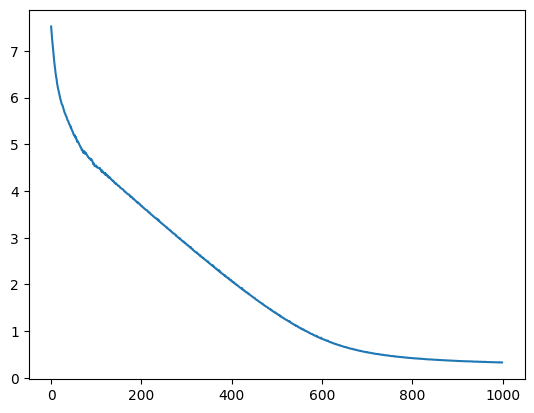

In [42]:
plt.plot(losses)
plt.show()

In [44]:
# Генерування передбачень
final_predictions = model(x)  # Зробіть передбачення для вхідних даних x
final_predicted_classes = (final_predictions >= 0.5).float()  # Перетворення ймовірностей у класи

# Створення DataFrame з трьома стовпцями
results_df = pd.DataFrame({
    'Фінальні передбачення': final_predictions.detach().numpy().flatten(),
    'Фінальні мітки': final_predicted_classes.detach().numpy().flatten(),
    'Справжні мітки': targets.flatten()
})

# Функція для зафарбовування рядків із невірними передбаченнями
def highlight_mismatch(row):
    color = 'background-color: rgba(255, 12, 0, 0.1)' if row['Фінальні мітки'] != row['Справжні мітки'] else ''
    return [color] * len(row)

# Застосування стилю
styled_df = results_df.style.apply(highlight_mismatch, axis=1).format("{:.2f}")

# Виведення таблиці
styled_df

,Фінальні передбачення,Фінальні мітки,Справжні мітки
0,0.57,1.00,0.00
1,0.68,1.00,1.00
2,0.90,1.00,1.00
3,0.16,0.00,0.00
4,0.88,1.00,1.00
5,0.57,1.00,0.00
6,0.68,1.00,1.00
7,0.90,1.00,1.00
8,0.16,0.00,0.00
9,0.88,1.00,1.00


In [45]:
# Обчислення точності моделі
accuracy = (final_predicted_classes == targets).float().mean()
print(f"\nТочність моделі: {accuracy.item() * 100:.2f}%")


Точність моделі: 80.00%
